# Stride reference solutions: fine-grid forward + coarse-grid FWI

This notebook produces three Stride reference solutions:

1. Fine-grid acoustic forward modelling for low-dispersion synthetic observations.
2. Coarse-grid Stride FWI from homogeneous water.
3. Coarse-grid Stride FWI from an exact-skull / water-interior start.

The forward and inverse problems use separate Stride grids and separate
IsoAcousticDevito operators. NumPy is used only for model construction,
trace-time interpolation, diagnostics, and saving files

running this notebook in the stride conda environment

## Configuration

The fine and inversion domains
have the same physical size, geometry, source pulse and shot ordering, but
different spatial and temporal discretisations.

In [1]:
import os
import time
import hashlib
from pathlib import Path
import stride_reference_fixed as ref
import importlib

ref = importlib.reload(ref)

helper_path = Path(ref.__file__).resolve()

print("Helper path:", helper_path)
print("Helper modified:", time.ctime(helper_path.stat().st_mtime))
print("Helper hash:", hashlib.sha256(helper_path.read_bytes()).hexdigest()[:12])
print("Working directory:", Path.cwd())
print("Process ID:", os.getpid())

Helper path: /Users/mp425/irp-mp425/friends/irp-ld2022/notebooks/sandbox/stride_reference_fixed.py
Helper modified: Fri Jun 26 09:01:02 2026
Helper hash: 3a2ef4c1c108
Working directory: /Users/mp425/irp-mp425/friends/irp-ld2022/notebooks/sandbox
Process ID: 2103


In [2]:
# os.environ["DISPLAY"] = ":0"
# os.environ["DEVITO_LANGUAGE"] = "C"
from devito import configuration
configuration["autotuning"] = "off"

%matplotlib inline

In [3]:
DOMAIN_M = 0.25
FINE_INTERIOR = (250, 250)
INV_INTERIOR = (125, 125)

F_CENTRE = 200e3 # centre frequency of 200kHz
N_CYCLES = 3
N_RECEIVERS =64 # should put even more as in breast 2d example
RESOLUTION_TAG = FINE_INTERIOR[0] # if (250,250) then res 250

In [4]:
import sys
import importlib
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import stride_reference_fixed as ref
importlib.reload(ref)
print("Devito config:", ref.configure_devito())
print("Helper version:", ref.REF_VERSION)

import mosaic
try:
    await mosaic.interactive("off")
except Exception as exc:
    print("Stop warning:", exc)

mosaic.clear_runtime()
print("Mosaic cleared")
import numpy as np
import matplotlib.pyplot as plt

from stride import (
    GradientDescent,  # FWI optimiser
    IsoAcousticDevito,  # wave-eq solver
    L2DistanceLoss,  # distance between modelled and observed data
    OptimisationLoop,
    ProcessGlobalGradient,
    ProcessModelIteration,
    ScalarField,
    adjoint,
    forward,
)

OUT = ref.reference_dir(RESOLUTION_TAG)
OUT

Devito config: serial C (macOS — avoids omp.h / libomp clash)
Helper version: 6
Mosaic cleared


PosixPath('/Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/250')

## 1. Build two complete Stride problems

problem_ref is used only to generate observations. problem_inv is the
coarser problem on which both FWI experiments are run.

In [5]:
# Clear stale Stride cache
# Delete cached acquisitions and inversion Vp iterates so the forward
# is re-run from scratch whenever the phantom or geometry changes.
import glob, os
patterns = [
    "shepp_logan_reference_*-Acquisitions.h5",
    "shepp_logan_inversion_*-Vp-*.h5",
]
deleted = []
for pat in patterns:
    for f in glob.glob(pat):
        os.remove(f)
        deleted.append(f)
if deleted:
    print(f"Cleared {len(deleted)} cached file(s):")
    for f in deleted:
        print(" ", f)
else:
    print("No cached files found.")

Cleared 13 cached file(s):
  shepp_logan_reference_250-Acquisitions.h5
  shepp_logan_inversion_125-Vp-00004.h5
  shepp_logan_inversion_125-Vp-00010.h5
  shepp_logan_inversion_125-Vp-00011.h5
  shepp_logan_inversion_125-Vp-00001.h5
  shepp_logan_inversion_125-Vp-00005.h5
  shepp_logan_inversion_125-Vp-00008.h5
  shepp_logan_inversion_125-Vp-00009.h5
  shepp_logan_inversion_125-Vp-00012.h5
  shepp_logan_inversion_125-Vp-00002.h5
  shepp_logan_inversion_125-Vp-00006.h5
  shepp_logan_inversion_125-Vp-00007.h5
  shepp_logan_inversion_125-Vp-00003.h5


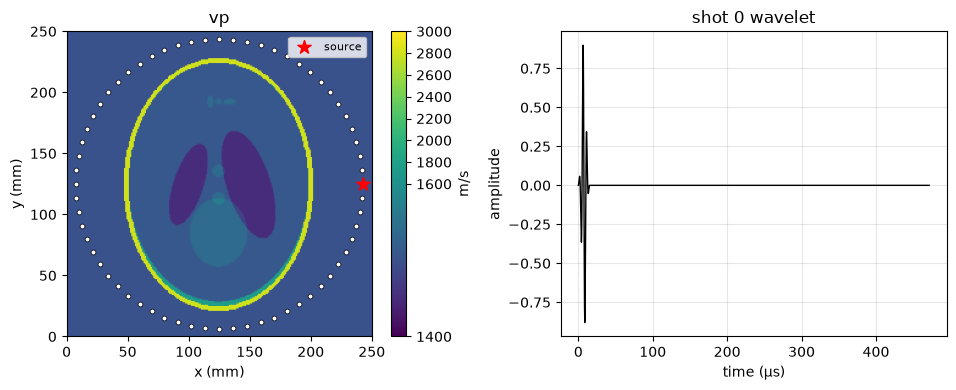

Fine grid: <stride.problem.domain.Grid object at 0x16c24a550>
Inverse grid: <stride.problem.domain.Grid object at 0x304267e90>
Fine dt=1.076e-07s, PPW at centre≈7.5
Inv  dt=2.160e-07s, PPW at centre≈3.7


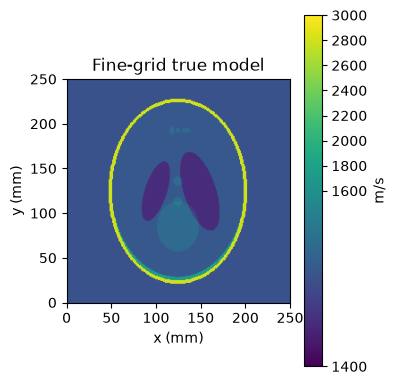

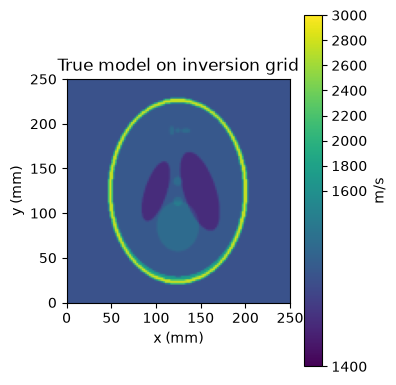

<Axes: title={'center': 'True model on inversion grid'}, xlabel='x (mm)', ylabel='y (mm)'>

In [6]:
problem_ref, vp_true_ref, vp_true_ref_array, meta_ref = ref.build_stride_problem(
    name=f"shepp_logan_reference_{RESOLUTION_TAG}",
    interior_shape=FINE_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,
)

ref.plot_vp_overview(
    problem_ref,
    vp_true_ref,
    domain_m=DOMAIN_M,
    shot_id=0,
)

problem_inv, vp_true_inv_field, _, meta_inv = ref.build_stride_problem(
    name=f"shepp_logan_inversion_{INV_INTERIOR[0]}",
    interior_shape=INV_INTERIOR,
    domain_m=DOMAIN_M,
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
    n_receivers=N_RECEIVERS,
    use_shepp_logan=False,  # grid/geometry only; truth is downsampled from fine grid below
)

# Downsample the fine-grid truth to the inversion grid so both grids share a
# consistent ground truth (rather than re-generating Shepp-Logan independently
# at 125x125, which gives a differently anti-aliased phantom).
vp_true_inv_array = ref.downsample_vp(vp_true_ref_array, INV_INTERIOR)
ref.fill_vp_from_numpy(vp_true_inv_field, vp_true_inv_array)

ref.save_vp_npy(vp_true_ref, OUT / "vp_true_fine.npy")
ref.save_vp_npy_from_array(vp_true_inv_array, OUT / "vp_true_inversion_grid.npy")
ref.save_grid_meta(
    problem_ref,
    OUT / "grid_meta_fine.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)
ref.save_grid_meta(
    problem_inv,
    OUT / "grid_meta_inversion.json",
    f_centre=F_CENTRE,
    n_cycles=N_CYCLES,
)



ppw_ref = ref.SOS_WATER / (F_CENTRE * meta_ref["spacing"][0])
ppw_inv = ref.SOS_WATER / (F_CENTRE * meta_inv["spacing"][0])

print("Fine grid:", problem_ref.grid)
print("Inverse grid:", problem_inv.grid)
print(f"Fine dt={meta_ref['dt']:.3e}s, PPW at centre≈{ppw_ref:.1f}")
print(f"Inv  dt={meta_inv['dt']:.3e}s, PPW at centre≈{ppw_inv:.1f}")

ref.plot_vp(vp_true_ref, domain_m=DOMAIN_M, title="Fine-grid true model")
ref.plot_vp(vp_true_inv_field, domain_m=DOMAIN_M, title="True model on inversion grid")

In [7]:
for location_id in range(N_RECEIVERS):
    ref_coord = np.asarray(
        problem_ref.geometry.get(location_id).coordinates
    )
    inv_coord = np.asarray(
        problem_inv.geometry.get(location_id).coordinates
    )

    if not np.allclose(ref_coord, inv_coord, atol=1e-12):
        raise RuntimeError(
            f"Geometry mismatch at location {location_id}: "
            f"reference={ref_coord}, inversion={inv_coord}"
        )

print("Reference and inversion coordinates are identical.")

Reference and inversion coordinates are identical.


In [8]:
coords_ref = np.array([
    problem_ref.geometry.get(i).coordinates
    for i in range(N_RECEIVERS)
])

coords_inv = np.array([
    problem_inv.geometry.get(i).coordinates
    for i in range(N_RECEIVERS)
])

print("Reference min/max:", coords_ref.min(axis=0), coords_ref.max(axis=0))
print("Inversion min/max:", coords_inv.min(axis=0), coords_inv.max(axis=0))
print("Maximum coordinate difference:",
      np.max(np.abs(coords_ref - coords_inv)))

Reference min/max: [0.0075 0.0065] [0.2425 0.2435]
Inversion min/max: [0.0075 0.0065] [0.2425 0.2435]
Maximum coordinate difference: 5.551115123125783e-17


## 2. Fine-grid Stride forward reference

This uses IsoAcousticDevito on problem_ref.grid. The generated observations
are saved and then resampled onto the inversion problem's time axis.

In [ ]:
runtime = await ref.ensure_mosaic_runtime(num_workers=3, log_level="info",
)
print("Mosaic ready, workers:", runtime.num_workers)

pde_ref = IsoAcousticDevito.remote(
    grid=problem_ref.grid,
    len=runtime.num_workers,
)

await forward(
    problem_ref,
    pde_ref,
    vp_true_ref,
    dump=True,
    kernel="OT4",
    fw3d_mode=True,
    interpolation_type="hicks",
)

ref.check_forward_ready(problem_ref)
ref.export_shot_observed_npy(
    problem_ref,
    OUT / "forward_fine",
)

print("Fine-grid observations saved to", OUT / "forward_fine")

Listening at <CommsManager object at 5778867344, uid=monitor, address=192.168.0.31, port=3000, state=connected>HEAD            Listening at <CommsManager object at 6170013200, uid=head, address=192.168.0.31, port=3002, state=connected>
Mosaic ready, workers: 3
MONITOR         Listening at <NODE:0 | WORKER:0-3>
WORKER:0:2      (ShotID 2) Spatial grid spacing (1.004 mm | 4.900 PPW) is higher than dispersion limit (0.984 mm | 5.000 PPW)
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:1      (ShotID 1) Spatial grid spacing (1.004 mm | 4.900 PPW) is higher than dispersion limit (0.984 mm | 5.000 PPW)
WORKER:0:1      AutoTuner: could not perform any runs
WORKER:0:2      (ShotID 3) Spatial grid spacing (1.004 mm | 4.900 PPW) is higher than dispersion limit (0.984 mm | 5.000 PPW)
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:0      (ShotID 0) Spatial grid spacing (1.004 mm | 4.900 PPW) is higher than dispersion limit (0.984 mm | 5.000 PPW)
WORKER:0:0      AutoTu

WORKER:0:2      (ShotID 4) Spatial grid spacing (2.016 mm | 4.500 PPW) is higher than dispersion limit (1.815 mm | 5.000 PPW)
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:1      (ShotID 2) Spatial grid spacing (2.016 mm | 4.500 PPW) is higher than dispersion limit (1.815 mm | 5.000 PPW)
WORKER:0:1      AutoTuner: could not perform any runs
WORKER:0:0      (ShotID 0) Spatial grid spacing (2.016 mm | 4.500 PPW) is higher than dispersion limit (1.815 mm | 5.000 PPW)
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:2      (ShotID 6) Spatial grid spacing (2.016 mm | 4.500 PPW) is higher than dispersion limit (1.815 mm | 5.000 PPW)
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:1      AutoTuner: could not perform any runs
WORKER:0:0      AutoTuner: could not perform any runs
WORKER:0:2      AutoTuner: could not perform any runs
WORKER:0:1      (ShotID 8) Spatial grid spacing (2.016 mm | 4.50

## 3. Transfer observations to the coarse Stride problem

The physical source/receiver geometry is unchanged. each receiver trace is
interpolated from the fine time sampling to problem_inv.time
soo:
- the same source and receiver geometry,
- the same shot ordering,
- the same physical experiment,
- but different time steps because their spatial grids are different

In [10]:
ref.transfer_observed_to_problem(
    problem_ref,
    problem_inv,
    check_geometry=True,
)

ref.export_shot_observed_npy(problem_inv, OUT / "observed_on_inversion_grid")
print(ref.observed_trace_difference(problem_ref, problem_inv, shot_id=0))

Forward OK: 64/64 shots with observed
{'source_shape': (64, 4384), 'target_shape': (64, 2184), 'source_max_abs': 3.6356265544891357, 'target_max_abs': 3.611058235168457}


### shot gather

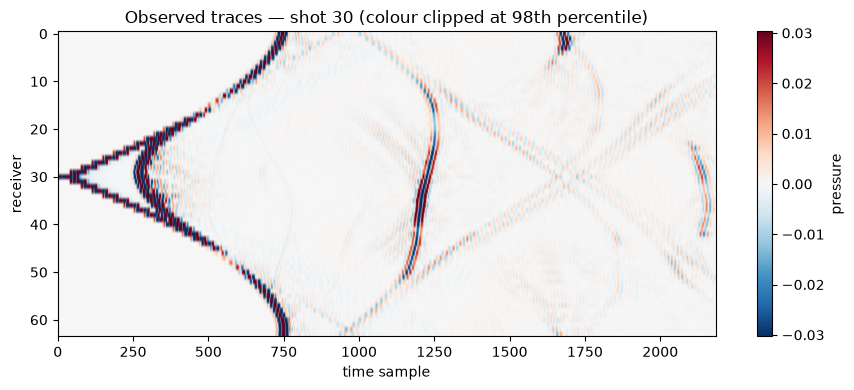

In [11]:
shot_id = 30
fine_trace = np.asarray(problem_ref.acquisitions.get(shot_id).observed.data)
inv_trace = np.asarray(problem_inv.acquisitions.get(shot_id).observed.data)

# Clip colour scale at 98th percentile so the strong direct arrival does not
# wash out the weaker skull/soft-tissue reflections.  The direct arrival will
# saturate (shown as solid red/blue) but all other arrivals become visible.
_clip = float(np.percentile(np.abs(inv_trace), 98))
trace_norm = plt.matplotlib.colors.TwoSlopeNorm(vmin=-_clip, vcenter=0.0, vmax=_clip)

# Trim the time axis: find the last sample with any signal above the clip
# threshold so the empty tail is not shown.
_signal_cols = np.where(np.max(np.abs(inv_trace), axis=0) > 1e-6 * _clip)[0]
_t_max = int(_signal_cols[-1] * 1.05) if len(_signal_cols) else inv_trace.shape[1]

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    inv_trace[:, :_t_max],
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=trace_norm,
)
ax.set_title(f"Observed traces — shot {shot_id} (colour clipped at 98th percentile)")
ax.set_xlabel("time sample")
ax.set_ylabel("receiver")
fig.colorbar(im, ax=ax, label="pressure")
plt.tight_layout()
plt.show()

## 4. Configure the coarse-grid Stride FWI operator

Both starts use the same observations, inverse grid, loss, frequency schedule,
shot selection and physical bounds.

In [12]:
max_freqs = [0.05e6, 0.06e6, 0.08e6, 0.1e6, 0.12e6, 0.13e6]  # starts with lower freq and gradually increase

# PPW check for each FWI stage (using minimum velocity = water)
print(f"{'Stage':<6} {'f_max':>10} {'PPW':>8}")
for i, f in enumerate(max_freqs, 1):
    ppw = ref.SOS_WATER / (f * meta_inv["spacing"][0])
    print(f"{i:<6} {f/1e3:>8.0f} kHz  {ppw:>5.1f}")

Stage       f_max      PPW
1            50 kHz   14.9
2            60 kHz   12.4
3            80 kHz    9.3
4           100 kHz    7.4
5           120 kHz    6.2
6           130 kHz    5.7


In [13]:
pde_inv = IsoAcousticDevito.remote(
    grid=problem_inv.grid,
    len=runtime.num_workers,
)

max_freqs = [0.05e6, 0.06e6, 0.07e6, 0.08e6, 0.1e6, 0.12e6]  #[0.06e6,0.08e6, 0.1e6, 0.12e6] # starts with lower freq and gradually increase
num_iters = 10
shots_per_iteration = 32
def make_fwi_components(vp):
    loss = L2DistanceLoss.remote(len=runtime.num_workers)
    optimiser = GradientDescent(
        vp,
        step_size=10,
        process_grad=ProcessGlobalGradient(),
        process_model=ProcessModelIteration(min=1400.0, max=3000.0),
    )
    return loss, optimiser, OptimisationLoop()
async def run_fwi(vp):
    ref.set_medium_vp(problem_inv, vp)
    ref.check_forward_ready(problem_inv)
    loss, optimiser, optimisation_loop = make_fwi_components(vp)
    # Track RMS error vs true model after each frequency band
    rms_history = []
    band_labels = []
    def _rms_vs_true():
        recovered = np.asarray(vp.data).ravel()
        true = vp_true_inv_array.ravel()
        return float(np.sqrt(np.mean((recovered - true) ** 2)))
    # Record starting RMS before any inversion
    rms_history.append(_rms_vs_true())
    band_labels.append("Initial")
    for _, frequency in optimisation_loop.blocks(len(max_freqs), max_freqs):
        await adjoint(
            problem_inv,
            pde_inv,
            loss,
            optimisation_loop,
            optimiser,
            vp,
            num_iters=num_iters,
            select_shots=dict(
                num=shots_per_iteration,
                every=2,
                randomly=False,
            ),
            f_max=frequency,
            max_freqs=max_freqs,
            save_undersampling=8,
            # All parameters below this line should also be passed to `forward`
            kernel='OT4',
            fw3d_mode=True,
            interpolation_type='hicks',
        )
        rms_history.append(_rms_vs_true())
        band_labels.append(f"{frequency/1e3:.0f} kHz")
    return vp, rms_history, band_labels

## 5. FWI from homogeneous water

The inversion parameter belongs to problem_inv.grid, not the fine reference
grid.

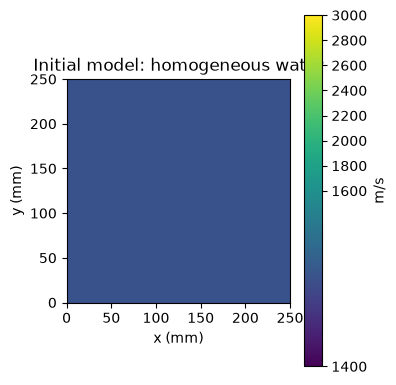

Forward OK: 64/64 shots with observed


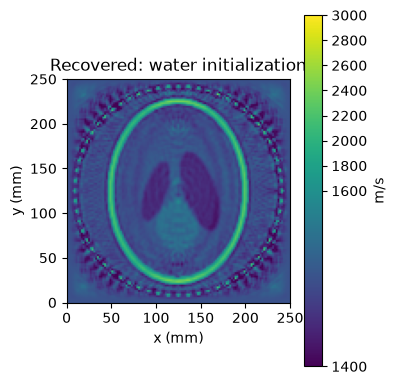

Water-start FWI saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/250/fwi/water_start


In [14]:
water_start_array = ref.water_model(INV_INTERIOR)

vp_water_start = ref.inversion_vp_from_array(
    problem_inv,
    water_start_array,
)

# Plot the initial homogeneous-water model
ref.plot_vp(
    water_start_array,
    domain_m=DOMAIN_M,
    title="Initial model: homogeneous water",
    vmin=1400,
    vmax=3000
)

# Run FWI
vp_water_recovered, _rms_water, _labels_water = await run_fwi(vp_water_start)

water_dir = OUT / "fwi" / "water_start"

ref.save_vp_npy(
    vp_water_recovered,
    water_dir / "vp_recovered.npy",
)

# Plot the recovered model
ref.plot_vp(
    vp_water_recovered,
    domain_m=DOMAIN_M,
    title="Recovered: water initialization",
    vmin=1400,
    vmax=3000
)

print("Water-start FWI saved to", water_dir)

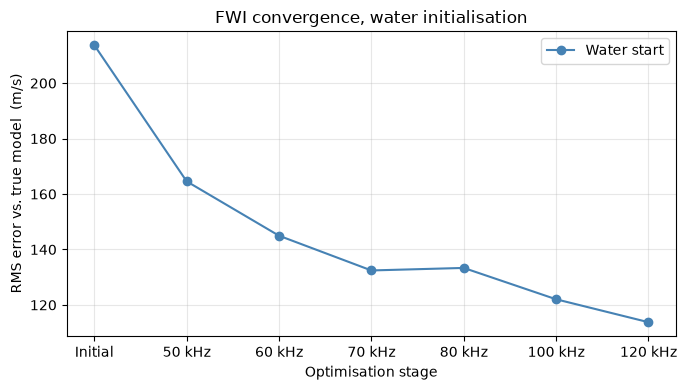

Water-start RMS: 213.7 -> 113.8 m/s


In [15]:
# Convergence: water start
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(_rms_water)), _rms_water, "o-", color="steelblue", label="Water start")
ax.set_xticks(range(len(_labels_water)))
ax.set_xticklabels(_labels_water)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, water initialisation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Water-start RMS: {_rms_water[0]:.1f} -> {_rms_water[-1]:.1f} m/s")

## 6. FWI from an exact-skull / water-interior start

This is not the complete true model. Only pixels classified as skull retain
their true inversion grid velocity, every non-skull pixel is reset to water

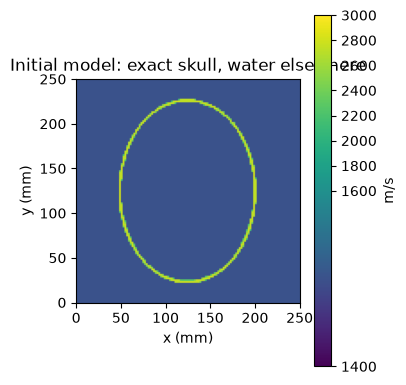

Forward OK: 64/64 shots with observed


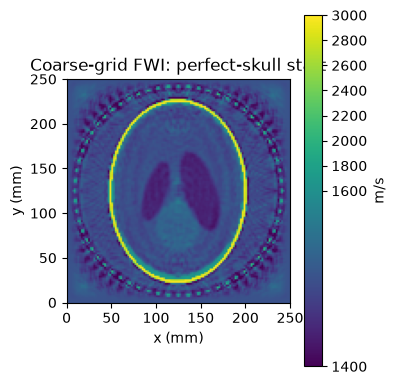

Perfect-skull-start FWI saved to /Users/mp425/irp-mp425/friends/irp-ld2022/inputs/reference/250/fwi/perfect_skull_start


In [16]:
perfect_skull_array, skull_mask = ref.perfect_skull_start(
    vp_true_inv_array,
    c_water=ref.SOS_WATER,
)

vp_perfect_skull_start = ref.inversion_vp_from_array(
    problem_inv,
    perfect_skull_array,
)

# Show INITIAL model
ref.plot_vp(
    perfect_skull_array,
    domain_m=DOMAIN_M,
    title="Initial model: exact skull, water elsewhere",
    vmin=1400,
    vmax=3000
)

# Run FWI
vp_perfect_skull_recovered, _rms_skull, _labels_skull = await run_fwi(vp_perfect_skull_start)

perfect_dir = OUT / "fwi" / "perfect_skull_start"

ref.save_vp_npy(
    vp_perfect_skull_recovered,
    perfect_dir / "vp_recovered.npy",
)
ref.plot_vp(
    vp_perfect_skull_recovered,
    domain_m=DOMAIN_M,
    title="Coarse-grid FWI: perfect-skull start",
    vmin=1400,
    vmax=3000

)
print("Perfect-skull-start FWI saved to", perfect_dir)

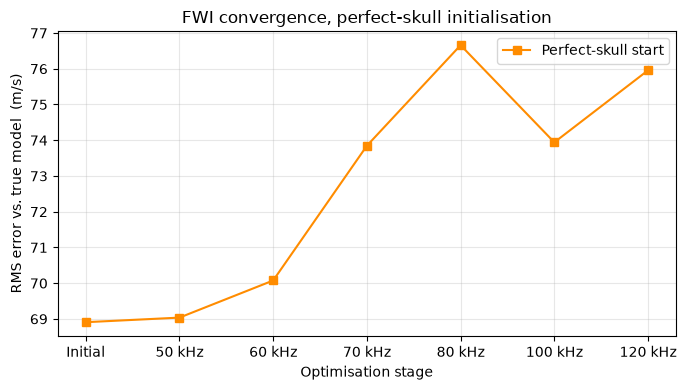

Perfect-skull RMS: 68.9 -> 76.0 m/s


In [17]:
# Convergence: perfect-skull start
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(_rms_skull)), _rms_skull, "s-", color="darkorange", label="Perfect-skull start")
ax.set_xticks(range(len(_labels_skull)))
ax.set_xticklabels(_labels_skull)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, perfect-skull initialisation")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Perfect-skull RMS: {_rms_skull[0]:.1f} -> {_rms_skull[-1]:.1f} m/s")

## 7. Compare and export

The FWI outputs are already on the intended inversion grid. No post-hoc
downsampling is used to pretend that a fine-grid inversion was coarse.

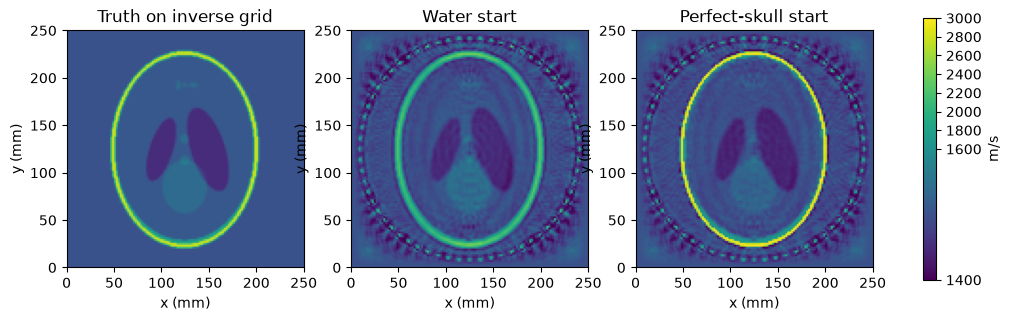

In [18]:
norm = ref.sos_norm(vmin=1400, vcenter=1600, vmax=3000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in [
    (axes[0], vp_true_inv_array, "Truth on inverse grid"),
    (axes[1], np.asarray(vp_water_recovered.data), "Water start"),
    (axes[2], np.asarray(vp_perfect_skull_recovered.data), "Perfect-skull start"),
]:
    im = ax.imshow(
        data.T,
        origin="lower",
        extent=ref.domain_extent_mm(DOMAIN_M),
        norm=norm,
    )
    ax.set_title(title)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

fig.colorbar(im, ax=axes.ravel().tolist(), label="m/s", shrink=0.85)
plt.show()

await mosaic.interactive("off")

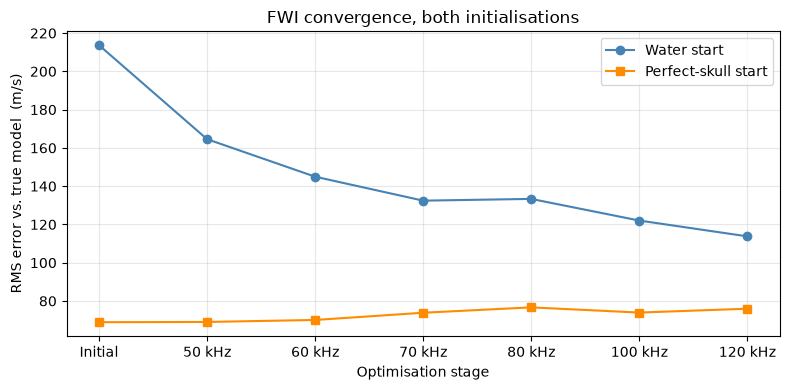

Water-start  : 213.7 -> 113.8 m/s  (46.8% improvement)
Perfect-skull: 68.9 -> 76.0 m/s  (-10.2% improvement)


In [19]:
# Combined convergence plot (both starts on one axes)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(_rms_water)), _rms_water,
        "o-", color="steelblue", label="Water start")
ax.plot(range(len(_rms_skull)), _rms_skull,
        "s-", color="darkorange", label="Perfect-skull start")
# x-ticks from water labels (same bands)
ax.set_xticks(range(len(_labels_water)))
ax.set_xticklabels(_labels_water)
ax.set_xlabel("Optimisation stage")
ax.set_ylabel("RMS error vs. true model  (m/s)")
ax.set_title("FWI convergence, both initialisations")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Water-start  : {_rms_water[0]:.1f} -> {_rms_water[-1]:.1f} m/s  "
      f"({100*(1 - _rms_water[-1]/_rms_water[0]):.1f}% improvement)")
print(f"Perfect-skull: {_rms_skull[0]:.1f} -> {_rms_skull[-1]:.1f} m/s  "
      f"({100*(1 - _rms_skull[-1]/_rms_skull[0]):.1f}% improvement)")

In [20]:
# Clear transferred observations so the forward solver actually runs
for shot in problem_inv.acquisitions.shots:
    if shot.observed is not None and shot.observed.allocated:
        shot.observed.deallocate()

## Grid convergence check: independently run 125×125 forward vs 250×250 forward
#
# Runs a fresh forward on problem_inv with vp_true_inv_field (no data from
# problem_ref involved). Compares the result to the fine-grid traces in
# physical time. Then restores the transferred observations so FWI is unaffected.

check_shot_gc = 30
check_rx_gc   = 0

# Step 1: run independent coarse forward
pde_inv_gc = IsoAcousticDevito.remote(grid=problem_inv.grid, len=runtime.num_workers)

await forward(
    problem_inv,
    pde_inv_gc,
    vp_true_inv_field,   # downsampled truth, not derived from problem_ref data
    dump=False,
)

# Save the independently computed coarse traces before restoring
coarse_indep = {
    shot.id: np.asarray(shot.observed.data, dtype=np.float32).copy()
    for shot in problem_inv.acquisitions.shots
    if shot.observed is not None and shot.observed.allocated
}
print(f"Independent coarse forward done: {len(coarse_indep)} shots saved")

# Step 2: restore the transferred observations for FWI
ref.transfer_observed_to_problem(problem_ref, problem_inv, check_geometry=True)
print("Transferred observations restored — FWI data intact")

# Step 3: compare in physical time
fine_t_gc   = ref.time_axis(problem_ref) * 1e6  # µs
coarse_t_gc = ref.time_axis(problem_inv) * 1e6  # µs

fine_rx_gc   = np.asarray(problem_ref.acquisitions.get(check_shot_gc).observed.data)[check_rx_gc]
coarse_rx_gc = coarse_indep[check_shot_gc][check_rx_gc]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(fine_t_gc,   fine_rx_gc,   lw=1,        label="Fine 250x250 (reference)")
ax.plot(coarse_t_gc, coarse_rx_gc, lw=1.5, ls="--", label="Coarse 125x125 (independent forward)")
ax.set_xlabel("time (µs)")
ax.set_ylabel("pressure")
ax.set_title(f"Grid convergence — receiver {check_rx_gc}, shot {check_shot_gc}: independent forwards")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Step 4: side-by-side gathers
fine_all_gc   = np.asarray(problem_ref.acquisitions.get(check_shot_gc).observed.data)
coarse_all_gc = coarse_indep[check_shot_gc]
_clip_gc  = float(np.percentile(np.abs(fine_all_gc), 98))
_norm_gc  = plt.matplotlib.colors.TwoSlopeNorm(vmin=-_clip_gc, vcenter=0.0, vmax=_clip_gc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, data, t_ax, label in [
    (axes[0], fine_all_gc,   fine_t_gc,   "Fine 250x250"),
    (axes[1], coarse_all_gc, coarse_t_gc, "Coarse 125x125 (independent)"),
]:
    im = ax.imshow(
        data,
        aspect="auto",
        origin="upper",
        cmap="RdBu_r",
        norm=_norm_gc,
        extent=[t_ax[0], t_ax[-1], data.shape[0], 0],
    )
    ax.set_title(label)
    ax.set_xlabel("time (µs)")
    ax.set_ylabel("receiver")
fig.suptitle("Different grids", y=1.02)
plt.tight_layout()
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="pressure")
plt.show()

# Step 5: timing and amplitude statistics
fine_peak_t_gc   = fine_t_gc[np.argmax(np.abs(fine_rx_gc))]
coarse_peak_t_gc = coarse_t_gc[np.argmax(np.abs(coarse_rx_gc))]
amp_ratio_gc     = float(np.max(np.abs(coarse_rx_gc))) / float(np.max(np.abs(fine_rx_gc)) + 1e-30)

print(f"\nGrid convergence statistics (receiver {check_rx_gc}, shot {check_shot_gc})")
print(f"  Fine   peak : {np.max(np.abs(fine_rx_gc)):.4e}  at {fine_peak_t_gc:.3f} µs")
print(f"  Coarse peak : {np.max(np.abs(coarse_rx_gc)):.4e}  at {coarse_peak_t_gc:.3f} µs")
print(f"  Amplitude ratio (coarse/fine) : {amp_ratio_gc:.4f}  (expect ≈ 1.0, small diff ok — different grid)")
print(f"  Peak-time difference          : {abs(fine_peak_t_gc - coarse_peak_t_gc):.4f} µs")
print(f"  Fine dt = {meta_ref['dt']*1e6:.4f} µs,  Coarse dt = {meta_inv['dt']*1e6:.4f} µs")

AttributeError: module mosaic has no attribute get_event_loop